<!-- COLAB-BADGE -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brendanpshea/computing_concepts_python/blob/main/v2/notebooks/COMP1150_NB10_OSNetworksWeb.ipynb)  
[Download .ipynb](https://raw.githubusercontent.com/brendanpshea/computing_concepts_python/main/v2/notebooks/COMP1150_NB10_OSNetworksWeb.ipynb) · [View on GitHub](https://github.com/brendanpshea/computing_concepts_python/blob/main/v2/notebooks/COMP1150_NB10_OSNetworksWeb.ipynb)


# Notebook 10: OS, Networks, Cloud & the Web — The Case of the Vanishing Website
### COMP 1150 — Computer Science Concepts
**Brendan Shea, PhD**

<!-- Lecture video link to be added -->
📺 **Lecture video:** *(coming soon)*

## Learning Outcomes

By the end of this notebook, you will be able to:

- Explain what an operating system does: managing processes, files, and memory
- Describe how a request crosses the internet: IP addresses, DNS, packets, and TCP
- Read an HTTP conversation: requests, responses, and status codes
- Call a real web API with Python's `requests` library and parse the JSON it returns
- Distinguish the cloud service models — IaaS, PaaS, and SaaS — and give an example of each
- Build and run a tiny web server with Flask, and explain the request/response cycle

*Maps to course LOs: 3*

## The Case of the Vanishing Website

**Irene Adler** runs Adler Streaming, a video platform with two million subscribers. This morning, it vanished.

Not for everyone. That's the maddening part. Support tickets say the site is down in Edinburgh but fine in Cardiff. Down on phones, fine on laptops. One customer watched half a film, refreshed, and got nothing.

Irene doesn't panic; she hires. Specifically, she hires **Baker Street Diagnostics**, a two-person consultancy run by **Sherlock Holmes** — a man who believes every technical failure is a crime scene — and **Dr. John Watson**, who translates Sherlock into English.

Sherlock's opening statement, delivered while Irene is still explaining:

> "Your website is not a place, Ms. Adler. It is a *conversation* — a request that leaves a customer's device, crosses machines you've never met, and returns with an answer. Somewhere along that road, the conversation is dying. We will follow the request. Every hop is a suspect. We eliminate them one at a time."

That sentence is this notebook's whole plan.

So far in this course, your programs have lived alone: one file, one machine, no outside world. But almost nothing you actually *use* works that way. Every app on your phone is a conversation between your device and distant computers — crossing an operating system, a network, and somebody's rented cloud.

To find Irene's fault, we have to understand every suspect on the road:

1. **The machine itself** — what an operating system actually does.
2. **The address lookup** — how `adlerstreaming.com` becomes a number a network can use.
3. **The journey** — packets, and the internet's delivery service.
4. **The conversation** — HTTP, the strict little language of the web.
5. **The server's home** — the cloud, and whose computer it really is.

And then the finale: the only way to truly understand a web server is to *become one*. At the end, you'll build and run your own.

## 1. The Machine Underneath: What an Operating System Does

Sherlock starts every case the same way: at the scene, with the body. Here, the "body" is a computer — and the first thing to understand about any computer is that your programs never actually touch it.

Between every program and the physical hardware sits the **operating system** (OS) — Windows, macOS, Linux, Android, iOS. It has three jobs that matter to us:

- **Processes.** A **process** is one running program. The OS starts them, stops them, and slices CPU time among them so that dozens can *appear* to run at once.
- **Files.** The OS owns the disk and organizes it into the **file system** — folders and files with names, so no program has to know where the physical bits live.
- **Memory.** The OS hands each process its own protected slice of memory, so a buggy game can't scribble over your open documents.

A useful mental picture: the OS is a building manager. Programs are tenants. Tenants never wire their own electricity — they ask the manager, and the manager deals with the building.

### The Crime Scene Is a Real Computer

Here's a fact that surprises most people: when you use Google Colab, you're not using "a website" — you've been lent a **real Linux computer** in a Google data center. And Linux will happily let us interrogate it.

In a code cell, a line starting with `!` is not Python — it's a command sent straight to the operating system. The next cell asks the OS to list its running **processes**. Run it in Colab and examine the scene.

In [1]:
#| eval: false
# Run this in Colab: every row is one process (one running program).
!ps aux | head -15

You'll see a table: each row is one process, with its ID number (`PID`), how much CPU and memory it's using, and the command that started it. Somewhere in that list you'll find `python3` — *that row is this notebook*. Your code is just one tenant among many, and the OS is managing all of them at once.

Now the other two jobs — files and memory. The next cell peeks at the top of the file system, then asks the OS how much memory it's handed out.

In [2]:
#| eval: false
# Run this in Colab: the top of the file system, then the memory situation.
!ls /
!free -h

The `ls /` listing shows the standard rooms of a Linux building — `home` (your files), `usr` (installed programs), `tmp` (scratch space). And `free -h` shows the memory ledger: total, used, available. Every byte your Python variables occupy was granted by the OS — and will be reclaimed by it when your process ends.

One picture ties the three jobs together. The diagram below shows where the OS sits.

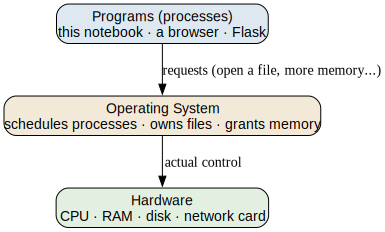

In [3]:
#| echo: false
#@title 📊 Diagram: where the operating system sits (click to show code)
import graphviz

g = graphviz.Digraph()
g.attr(rankdir="TB", bgcolor="transparent")
g.attr("node", shape="box", style="rounded,filled", fontname="Helvetica")

g.node("apps", "Programs (processes)\nthis notebook · a browser · Flask", fillcolor="#dde8f0")
g.node("os", "Operating System\nschedules processes · owns files · grants memory", fillcolor="#f3e9d8")
g.node("hw", "Hardware\nCPU · RAM · disk · network card", fillcolor="#e3efe1")

g.edge("apps", "os", label="  requests (open a file, more memory...)")
g.edge("os", "hw", label="  actual control")
g

**Reading it:** every arrow passes through the middle box. Programs at the top never command the hardware directly — they *ask* the OS, and the OS decides. That protection is why one crashing app doesn't take down your whole machine (and why, when a whole *server* goes silent, the OS's process table is the first place a detective looks — remember that for later).

### ✏️ Your Turn — The Scene of the Machine

Sherlock leaves you at the scene with three questions. Answer each by running a command in Colab (use the two cells above as models):

1. How many processes mention `python` in their command? (Try `!ps aux | grep python`.)
2. What's inside the `/tmp` directory right now?
3. Roughly how much memory is *available* on your Colab machine?

In [4]:
#| eval: false
# TODO: your three investigation commands, one per line.

### 💭 Think About It — Three Hundred Tenants

Your phone is running a few hundred processes *right now* — and you've never had to know that until this sentence.

That ignorance is a designed gift: the OS hides the machine so completely that most people never meet it. What's one other system in your life (not a computer) that works hard so you can ignore it? What happens when *that* one breaks?

## 2. Finding the Address: DNS and IP

The Colab machine checks out — suspect one eliminated. Sherlock moves to the road itself, and brings in a specialist: **Mary Morstan**, whose company, Morstan Logistics, moves fifty thousand parcels a day.

Mary's rule: *"You can't deliver to a name. You deliver to an address."*

The internet agrees. Every machine on a network has an **IP address** — a number like `142.250.187.206`. Numbers, not names, are what the network routes. But nobody types numbers. You type `adlerstreaming.com`, and something must translate.

That something is **DNS** — the Domain Name System: the internet's phone book, translating names into IP addresses millions of times per second, invisibly, before any real conversation begins.

Python can ask DNS directly. The general pattern:

```
socket.gethostbyname("website name")
```

The next cell looks up three real names.

In [5]:
import socket

for site in ["google.com", "wikipedia.org", "python.org"]:
    print(f"{site:16} -> {socket.gethostbyname(site)}")

google.com       -> 142.251.218.174
wikipedia.org    -> 208.80.154.224
python.org       -> 151.101.64.223


Three names, three numeric addresses — you just used the same lookup your browser performs before loading any page. (Run it twice on different days and `google.com` may answer with *different* numbers. Big sites have many machines behind one name; DNS hands out addresses like a receptionist directing a queue.)

And here is **suspect two** in Irene's case: if a region's DNS servers hold a stale or wrong address, the site "vanishes" — for those users only. Everyone else, using healthy phone books, sees nothing wrong. It fits the Edinburgh tickets... but Sherlock isn't done eliminating.

### The Journey: Packets and TCP

Once your device has the address, Mary's world takes over completely — because data travels the way parcels do.

A message isn't sent whole. It's chopped into **packets** — small chunks, each stamped with the destination address and a sequence number — and each packet finds its *own* way across the network, hopping from router to router. They can arrive out of order. Some don't arrive at all.

The internet's fix is a protocol called **TCP**, and it works exactly like Mary's tracking system:

1. Number every parcel in the shipment.
2. The receiver confirms each one that arrives.
3. Anything unconfirmed gets re-sent.
4. Reassemble in numbered order — the message arrives complete, or the sender knows it didn't.

The diagram below is Sherlock's suspect map: the full road a request travels. Keep it in mind for the rest of the case.

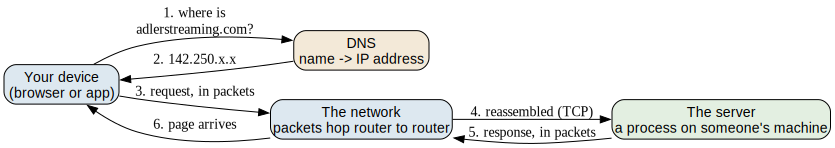

In [6]:
#| echo: false
#@title 📊 Diagram: the road a request travels — the suspect map (click to show code)
import graphviz

g = graphviz.Digraph()
g.attr(rankdir="LR", bgcolor="transparent")
g.attr("node", shape="box", style="rounded,filled", fontname="Helvetica", fillcolor="#dde8f0")

g.node("browser", "Your device\n(browser or app)")
g.node("dns", "DNS\nname -> IP address", fillcolor="#f3e9d8")
g.node("net", "The network\npackets hop router to router")
g.node("server", "The server\na process on someone's machine", fillcolor="#e3efe1")

g.edge("browser", "dns", label="1. where is\nadlerstreaming.com?")
g.edge("dns", "browser", label="2. 142.250.x.x")
g.edge("browser", "net", label="3. request, in packets")
g.edge("net", "server", label="4. reassembled (TCP)")
g.edge("server", "net", label="5. response, in packets")
g.edge("net", "browser", label="6. page arrives")
g

**Reading it:** follow the numbers. The name lookup (1–2) happens *before* the real request; the request and response (3–6) each cross the network as packets that TCP reassembles. Every box is one of Sherlock's suspects: the device, the phone book, the road, the server.

### ✏️ Your Turn — Mary's Address Book

Mary wants a mini address book. Look up the IP addresses of **three websites you actually use** (pick your own). Then run your lookups a second time.

Did any address change between runs — or differ from a classmate's result for the same site? Write one sentence proposing *why* a single name might answer with different numbers.

In [7]:
#| eval: false
import socket

# TODO: look up three sites you use. Run it twice. Compare.
my_sites = ["", "", ""]

## 3. The Conversation: HTTP

The road is clear — Mary's packets are flowing. Sherlock turns to what's *said* on that road. Time to question Irene's site directly, in its own language.

The web's language is **HTTP** (HyperText Transfer Protocol), and it is a rigidly polite conversation with exactly two turns:

- **The request** — your device says: a *verb* (usually `GET`, meaning "please send me...") plus an address.
- **The response** — the server answers with two things: the content, and a three-digit **status code** saying how it went.

Sherlock reads status codes the way he reads witnesses:

| Code | Meaning | Sherlock's translation |
|---|---|---|
| **200** | OK | "The witness is cooperating." |
| **301** | Moved permanently | "He's given a forwarding address." |
| **404** | Not found | "There is no such person at this address." |
| **500** | Server error | "The witness has fainted mid-sentence." |

### Making Requests in Python

Python speaks HTTP through the `requests` library. The pattern couldn't be shorter:

```
response = requests.get("the URL")
response.status_code   # the three-digit verdict
response.json()        # the content, if it's JSON
```

Let's question a real server. Open-Meteo is a free weather service with an API — and since the next section of this case takes us to London, the next cell asks for the current weather near Baker Street.

In [8]:
import requests

url = "https://api.open-meteo.com/v1/forecast"
response = requests.get(url, params={
    "latitude": 51.52, "longitude": -0.16,   # Baker Street, London
    "current_weather": True,
})

print("Status code:", response.status_code)
print(response.json()["current_weather"])

Status code: 200
{'time': '2026-07-07T13:00', 'interval': 900, 'temperature': 29.4, 'windspeed': 13.7, 'winddirection': 302, 'is_day': 1, 'weathercode': 1}


### Understanding the Code

- `requests.get(url, params=...)` sent a real HTTP request across the real internet — DNS lookup, packets, TCP, everything from the suspect map, in one line.
- `response.status_code` came back `200`: the witness cooperated.
- `response.json()` converted the reply into Python data. The server answered in **JSON** — labeled, nested data that arrives as dictionaries and lists you already know how to handle.

A server whose job is answering programs (rather than showing pages to humans) is called an **API** — an *application programming interface*. This is **Dr. Watson's** world: his telehealth app never scrapes weather off a webpage; it asks an API and gets clean JSON. Most modern software is exactly this — programs having HTTP conversations with other programs.

### 🔮 Predict Before You Run

The next cell deliberately asks GitHub's API for a page that does not exist.

Look at Sherlock's status-code table above. **Before running it**, write down the code you expect.

In [9]:
import requests

response = requests.get("https://api.github.com/this-page-does-not-exist")
print("Status code:", response.status_code)

Status code: 404


**404 — no such person at this address.** Note what *didn't* happen: no crash, no silence. The server answered, calmly, with a code meaning "that's not a thing." Good HTTP conversations fail *informatively* — and a diagnostician like Sherlock learns as much from a 404 as from a 200.

(As for Irene's site? Her servers are returning 200s... when the request reaches them at all. Suspects three and four — the road and the conversation — are eliminated. The circle tightens.)

### ✏️ Your Turn — Irene's Weather Wall

Irene wants a weather widget for her office wall: the current weather for a city of *your* choice.

Find your city's rough latitude and longitude (search engines answer this instantly), call the Open-Meteo API like the example above, and print **just two things**: the temperature and the wind speed, pulled out of the JSON by key.

In [10]:
#| eval: false
import requests

# TODO: your city's coordinates, one API call, print temperature and windspeed only.
my_latitude =
my_longitude =

## 4. Whose Computer Is It Anyway? The Cloud

One suspect left: the server itself. But before we knock on its door, Sherlock asks his brother a deceptively simple question: *where does a website live?*

**Mycroft Holmes** runs the Whitehall Cloud Office — he decides where the government's systems live — and his answer is the least mystical definition you'll ever hear:

> "The **cloud** is someone else's computer. Rented by the slice, billed by the hour, reachable over the network. The only interesting question is *how big a slice* you rent."

That question — how much of the machine is your problem versus the landlord's — has exactly three standard answers, and a housing analogy makes them stick:

- **IaaS** (*Infrastructure as a Service*) — **rent bare land.** You get raw virtual machines; you install and manage everything above the hardware. Total control, total responsibility. (Amazon EC2.)
- **PaaS** (*Platform as a Service*) — **rent an apartment.** You bring only your code; the landlord runs the machines, the OS, the plumbing. (Heroku, Google App Engine.)
- **SaaS** (*Software as a Service*) — **book a hotel room.** You just *use* finished software through a browser; nothing underneath is your problem. (Gmail, Google Docs.)

One more row for the table: **you've been a cloud customer this whole course.** Colab is finished software you use through a browser (SaaS) — that hands you a managed machine to run code on (which is what a PaaS does). The Linux box you interrogated in section 1? A slice of someone else's computer, exactly as Mycroft says.

| Model | Housing version | You manage | Example |
|---|---|---|---|
| IaaS | bare land | OS, software, code — everything | Amazon EC2 |
| PaaS | apartment | just your code and data | Heroku, App Engine |
| SaaS | hotel room | nothing — you're a user | Gmail, Colab |

And Irene? Adler Streaming rents from a PaaS. Which means the last suspect — her server — is a *process running on a machine she has never seen.* Hold that thought.

### 💭 Think About It — Mycroft's Dilemma

Mycroft must decide where the national health records system lives: on servers the government owns and staffs, or rented from a giant cloud provider that runs infrastructure better than any government ever has.

Give one strong reason for each choice. Then the harder question: who should hold the keys to data like that — and is "whoever runs servers best" the right answer?

## 5. Becoming the Server

Four suspects eliminated: the client machine, DNS, the network, the HTTP conversation. What remains, however improbable, must be the truth — the fault is *at the server*.

But what actually **is** a server? Strip away the mystique and it's almost disappointing:

> A **server** is a program that waits. It listens for HTTP requests, and for each one, it runs some code and returns a response.

That's it. It's a process — a tenant of some operating system, like every program in section 1. And the fastest way to understand one is to *be* one. Python's most popular tool for this is **Flask**, and its whole shape fits in a skeleton:

```
app = Flask(__name__)

@app.route("/some/path")
def handler():
    return "the response"
```

Each `@app.route(...)` line declares: *when a request arrives for this path, run this function and send back whatever it returns.* A path-plus-function pair is called a **route**.

### Mrs. Hudson Opens the Doors

Naturally, our server will be hosted by a landlady. **Mrs. Hudson** — of Hudson Hosting — presents the next cell: a complete, working web server in about a dozen lines.

Two notes before you run it **in Colab**:

- The `serve_kernel_port_as_window` line is Colab magic: it opens a link to your server in a new browser tab.
- `app.run(...)` **runs forever** — that's the whole point of a server; it waits. The cell will show a spinner. When you're done visiting your site, press the cell's **stop button**.

In [11]:
#| eval: false
from flask import Flask
from google.colab.output import serve_kernel_port_as_window

app = Flask(__name__)

@app.route("/")
def home():
    return "<h1>221B Web Services</h1><p>Mrs. Hudson welcomes you.</p>"

@app.route("/api/status")
def status():
    return {"service": "221B Web Services", "status": "open", "cases_solved": 47}

serve_kernel_port_as_window(5000)
app.run(port=5000)

Click the link Colab prints, and you are *visiting your own website* — served by a process you started, on a rented Linux machine in a data center. Add `/api/status` to the address and you'll get JSON: you've built an API, the very kind you *consumed* in section 3. (Returning a dictionary from a route is all it takes — Flask converts it to JSON for you.)

Trace one full visit against the suspect map: browser → (address lookup) → packets → **your process** → its return value → packets → rendered page. The **request/response cycle**, end to end — and this time you own the last box.

*(Want a link that works on your phone, off Colab? A tool called `pyngrok` can tunnel your server to a public URL — it needs a free ngrok account and token, so we leave it as an optional side quest.)*

### Case Closed

Armed with all five layers, Sherlock reads Adler Streaming's server logs — and the culprit is almost insultingly mundane.

One of Irene's three server processes **crashed two days ago**. Nothing restarted it. The two survivors handled the load most of the time — but whenever traffic spiked, requests routed to the dead tenant's address simply... vanished. Down in Edinburgh, fine in Cardiff; down at 8 PM, fine at 3 AM.

One `ps` on the right machine — section 1, the very first tool in this notebook — would have shown a process table with a corpse in it. Sherlock's verdict: *"Your website did not vanish, Ms. Adler. One-third of it stopped existing, and nobody was watching the tenants."*

The fix is a monitor that restarts dead processes. The lesson is the notebook: **the web is layers, and every layer is just something you now understand.**

### ✏️ Your Turn — Your Own Route

Reopen Mrs. Hudson's server cell and add a **third route** at the path `/about` that returns a short HTML paragraph about *you* (or your favorite detective).

Re-run the cell, visit `/about`, and confirm your page is live. Then, for one bonus mark of Sherlock's respect: visit a path you *didn't* define and note what Flask returns.

In [12]:
#| eval: false
# TODO: copy the server from above, add an /about route, re-run, visit it.

## ✏️ Capstone — The Baker Street Tip Line

Time to run your own corner of the web. You'll design a small web service and have an AI assistant (Gemini, Claude, or ChatGPT) write the Flask code — while you make the design decisions and verify every route.

**The default theme:** an anonymous tip line for Baker Street Diagnostics — a home page, an API route serving the current tips as JSON, and a route that looks up one tip by number. **Or reskin it**: a fan site with an API, a team status board, a restaurant menu service. Any theme with a page + data works.

### Step 0 — Design First (before touching the AI)

In the cell below, write your design as plain text:

- Your **three routes**: their paths, and what each returns (HTML page or JSON?)
- The data behind them (a list of dictionaries is plenty — no database needed)
- One route must take a **URL parameter** — like `/tip/2` returning tip #2

*(Double-click and write your design here.)*

**Route 1:** ...

**Route 2:** ...

**Route 3:** ...

**The data:** ...

### Step 1 — Build It *(prompt #1)*

Turn your design into a prompt. A skeleton to fill in:

> I'm learning Flask in Google Colab. Write a complete Flask app with these three routes: **[paste your design]**.
> Store the data as a Python list of dictionaries defined at the top.
> Use `from google.colab.output import serve_kernel_port_as_window`, call `serve_kernel_port_as_window(5000)` just before `app.run(port=5000)`.
> One code block, no explanations.

Paste the result below, run it, and **visit every route** in the opened tab. Don't move on until all three answer.

In [13]:
#| eval: false
# ✏️ Paste your AI-built Flask app here, run it, and visit every route.

### Step 2 — Question Your Own Witness *(prompt #2)*

In section 3 you interrogated other people's servers with `requests`. Now interrogate **your own** — the two halves of this notebook shaking hands.

While your server cell is running, open Colab's *second* trick: you can't easily `requests.get` your own Colab tab from outside, so test like a detective instead:

1. Visit your JSON route in the browser — is it valid JSON? Every field you designed?
2. Visit your parameter route with a number that **exists** — right answer?
3. Visit it with a number that **doesn't exist** — what happens? (If it crashes with an ugly error page: that's a finding. Ask the AI to make it return a polite JSON message and a `404` status instead.)

In [14]:
#| eval: false
# ✏️ Paste your improved app here (with the polite 404 handling), re-run, re-test.

### Step 3 — One Extension, Then Reflect

Add **one** bell or whistle — your choice: a route that returns *how many* tips there are; a search route like `/tips/urgent`; or a home page that lists links to every other route. Re-test everything after (a change that breaks an old route is the oldest bug in the book).

Then reflect below, 2–3 sentences: What did the AI get wrong or almost-wrong? What did you only catch by *visiting the routes yourself*?

*AI is a fast first draft. You verify.*

In [15]:
#| eval: false
# ✏️ Paste your final, extended app here.

*(Your 2–3 sentence reflection — double-click to edit.)*

## Key Terms

- **API (application programming interface)** — A server whose job is answering programs rather than people, usually in JSON.
- **Cloud** — Computers owned by someone else, rented over the network by the slice.
- **DNS (Domain Name System)** — The internet's phone book: translates names like `python.org` into IP addresses.
- **File system** — The OS's organization of storage into named files and folders.
- **Flask** — A small Python library for building web servers.
- **HTTP** — The web's request/response language, spoken between clients and servers.
- **IaaS / PaaS / SaaS** — The three cloud rental sizes: raw machines / a platform for your code / finished software.
- **IP address** — The numeric address that identifies a machine on a network.
- **Operating system (OS)** — The software layer that manages processes, files, and memory between programs and hardware.
- **Packet** — A small, addressed chunk of data; messages cross the internet as many packets.
- **Process** — One running program, managed (started, scheduled, stopped) by the OS.
- **Request/response cycle** — The full round trip: client asks, server's code runs, answer returns.
- **Route** — In a web server, one path (like `/api/status`) paired with the function that answers it.
- **Server** — A program that waits for requests and returns responses.
- **Status code** — The three-digit verdict in every HTTP response: 200 OK, 404 not found, 500 server error.
- **TCP** — The protocol that numbers, confirms, re-sends, and reassembles packets so messages arrive complete.

## Summary

Every app is a conversation across layers, and you now know each one. The operating system runs processes, owns files, and grants memory — programs never touch hardware directly. DNS turns names into IP addresses; TCP moves data as numbered, confirmed packets. On top of that road, HTTP holds a strict two-turn conversation of requests and responses, with status codes as verdicts — and an API is just a server that answers programs in JSON. The cloud is someone else's computer rented in three sizes (IaaS, PaaS, SaaS). And a web server, demystified, is a program that waits: with Flask, a dozen lines make you a citizen of the web rather than a visitor. When something "vanishes," it's one of these layers — and now you know how to interrogate every suspect.

## What's Next

You just built a server and opened its door to the network. Here's the thought that should keep you up tonight: *anyone* can knock. The next notebook is about exactly that — security. Who else is sending requests to your server, what are they after, and how do systems defend the data behind the door?

*COMP 1150 — Computer Science Concepts · Brendan Shea, PhD*
*Content licensed under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).*